### 1.Import Thư viện

In [11]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

### 2.Đọc dữ liệu từ file CSV

In [12]:

columns = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]

df = pd.read_csv(
    "pima-indians-diabetes.data.csv",
    header=None,
    names=columns
)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### 3.Tiền xử lý dữ liệu

In [14]:
# Các giá trị 0 không hợp lệ về mặt sinh lý
invalid_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

df[invalid_cols] = df[invalid_cols].replace(0, np.nan)

# Điền giá trị thiếu bằng median
df.fillna(df.median(), inplace=True)

df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

### 4.Chuẩn hóa & phân cụm K-means (K = 4)

In [15]:
# Chọn các đặc trưng chính
X = df[["Glucose", "BMI", "Age"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Cluster
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,2
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,1
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,3
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,1
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,0


### 5.Biểu đồ 1 - Phân cụm bệnh nhân theo Glucose & BMI

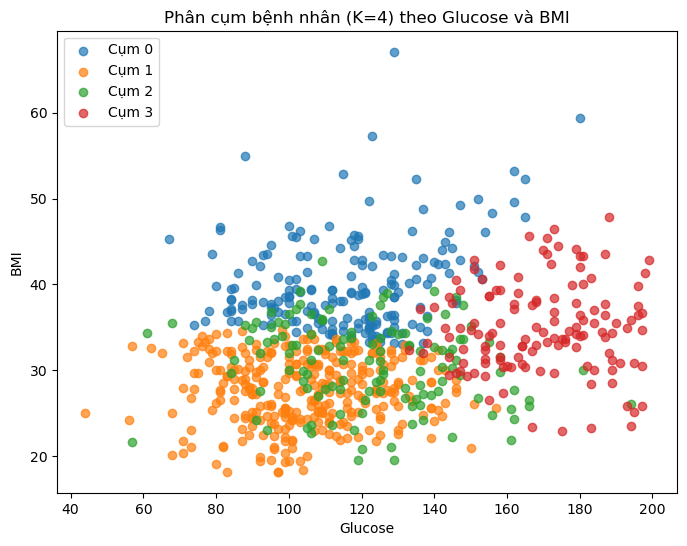

In [16]:
plt.figure(figsize=(8, 6))

for cluster in range(4):
    subset = df[df["Cluster"] == cluster]
    plt.scatter(
        subset["Glucose"],
        subset["BMI"],
        label=f"Cụm {cluster}",
        alpha=0.7
    )

plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.title("Phân cụm bệnh nhân (K=4) theo Glucose và BMI")
plt.legend()
plt.show()

### 6.Biểu đồ 2-Phân bố cụm theo Tuổi & Glucose

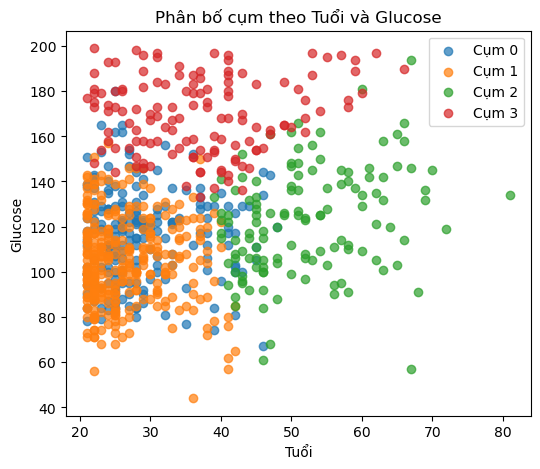

In [17]:
plt.figure(figsize=(6, 5))

for cluster in range(4):
    subset = df[df["Cluster"] == cluster]
    plt.scatter(
        subset["Age"],
        subset["Glucose"],
        label=f"Cụm {cluster}",
        alpha=0.7
    )

plt.xlabel("Tuổi")
plt.ylabel("Glucose")
plt.title("Phân bố cụm theo Tuổi và Glucose")
plt.legend()
plt.show()

### 7.Biểu đồ 3 - Phân bố cụm theo BMI & Glucose

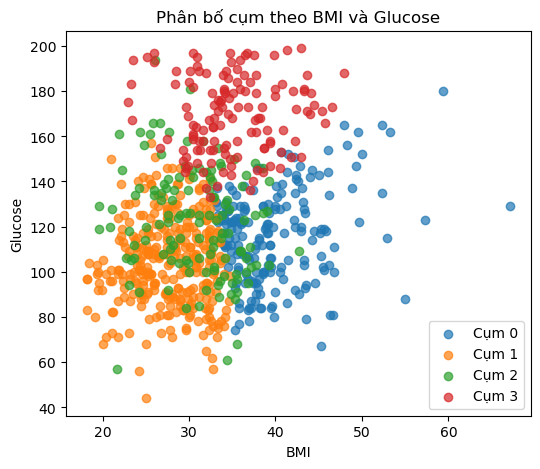

In [18]:
plt.figure(figsize=(6, 5))

for cluster in range(4):
    subset = df[df["Cluster"] == cluster]
    plt.scatter(
        subset["BMI"],
        subset["Glucose"],
        label=f"Cụm {cluster}",
        alpha=0.7
    )

plt.xlabel("BMI")
plt.ylabel("Glucose")
plt.title("Phân bố cụm theo BMI và Glucose")
plt.legend()
plt.show()

### 8.Biểu đồ 4 -Tỷ lệ mắc bệnh theo từng cụm

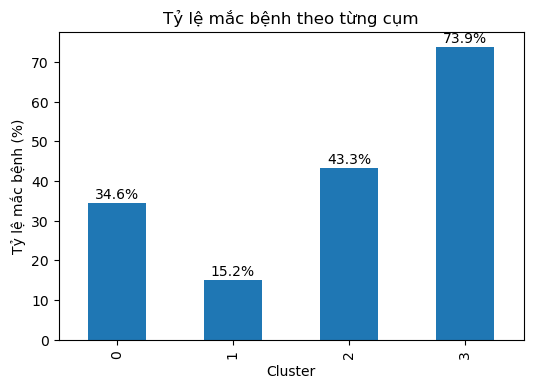

In [19]:
cluster_rate = df.groupby("Cluster")["Outcome"].mean() * 100

plt.figure(figsize=(6, 4))
cluster_rate.plot(kind="bar")

plt.ylabel("Tỷ lệ mắc bệnh (%)")
plt.title("Tỷ lệ mắc bệnh theo từng cụm")

for i, v in enumerate(cluster_rate):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center")

plt.show()

### 9.Biểu đồ 5 - Phân bố số lượng bệnh nhân theo cụm

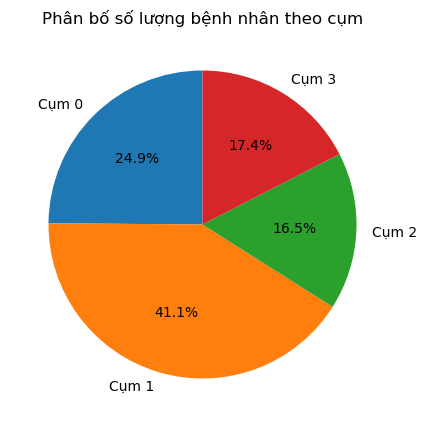

In [20]:
cluster_counts = df["Cluster"].value_counts().sort_index()

plt.figure(figsize=(5, 5))
plt.pie(
    cluster_counts,
    labels=[f"Cụm {i}" for i in cluster_counts.index],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Phân bố số lượng bệnh nhân theo cụm")
plt.show()